There are many resources online that talk about the qualitative differences between various direct trajectory optimization methods like direct shooting, multiple shooting, collocation, etc. But I haven't really found a comprehensive collection of simple implementations that highlight the differences. Hopefully this page can be that collection. I'm going to assume that the audience here is already familiar with at least one form of trajectory optimization.

Across all direct methods, a NonLinear Program (NLP) is constructed that discretizes or approximates the continuous time trajectory optimization problem. There are a few consistent components across any formulation of trajectory optimization.
1. The cost function
2. Dynamic constraints
3. Boundary conditions
4. Other constraints

In order to focus in on the methods themselves, we'll simplify as much of the problem as we can and keep them standardized across implementations.
1. Quadratic, positive definite cost function to maintain convexity.
2. Simple pendulum dynamics. If dynamics are linear, the differences between some methods become irrelevant. 
3. Identical initial condition, and fixed final state. 

In order to solve the NLP, we'll employ Sequential Quadratic Programming. 

In [1]:
import casadi as ca
import matplotlib.pyplot as plt
import numpy as np

-0.405928 -0.913905


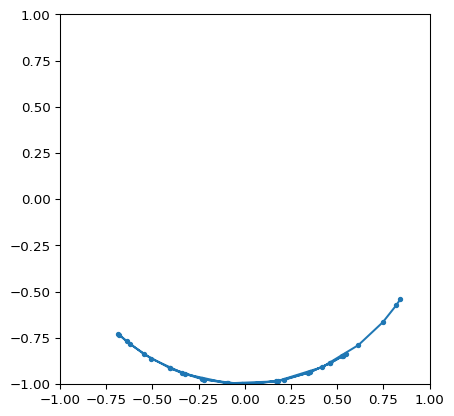

In [2]:
n = 2
m = 1

b = 0.5
m = 1
l = 1
g = 9.81

def continuous_dynamics(state, control):
    theta, dtheta = state[0], state[1]
    return ca.vertcat(dtheta, -b/m/l**2 * dtheta - g/l*ca.sin(theta) + control/m/l**2)
    
dt = 0.1

def rk4_integration(state, control):
    k1 = continuous_dynamics(state, control)
    k2 = continuous_dynamics(state + dt/2*k1, control)
    k3 = continuous_dynamics(state + dt/2*k2, control)
    k4 = continuous_dynamics(state + dt*k3, control)
    return state + dt/6 *(k1 + 2*k2 + 2*k3 + k4)

num_steps = 30
initial_state = [1.0, 0.0]
goal_state = [np.pi, 0.0]

def simulate(initial_state, policy, num_steps, dt, k_0=0):
    states = [initial_state]
    controls = []
    for step in range(num_steps):
        control = policy(states[-1], step+k_0)
        state = rk4_integration(states[-1], control)
        states.append(state)
        controls.append(control)
    return states, controls

fig, ax = plt.subplots()
def no_control_policy(state, step):
    return 0
states, controls = simulate(initial_state, no_control_policy, num_steps, dt)
xs = ca.vcat([l*ca.sin(state[0]) for state in states])
ys = ca.vcat([-l*ca.cos(state[0]) for state in states])
ax.plot(xs, ys, ".-")
ax.set_aspect("equal")
ax.set_ylim([-1, 1])
ax.set_xlim([-1, 1])
print(xs[-1], ys[-1])

## Direct Shooting

Start with an initial trajectory. Optimize over an approximation. Your solution will likely not attain your goal point because you linearized around your guess. Solve again until your constraints are satisfied.

In [3]:
num_steps = 30
opti = ca.Opti()

controls = opti.variable(num_steps, m)
state_0 = opti.parameter(n)
state_f = opti.parameter(n)

def open_loop_policy(state, k):
    return controls[k]

states, _ = simulate(state_0, open_loop_policy, num_steps, dt)

print("Setting Cost")
Q = np.diag([10., 1.])
R = np.diag([0.1])
cost = 0
for step in range(num_steps):
    cost += ca.mtimes([(states[step] - state_f).T, Q, states[step] - state_f]) + ca.mtimes([controls[step], R, controls[step].T])

opti.minimize(cost)

print("Setting Constraints")
opti.subject_to(states[-1] == state_f)
opti.subject_to(opti.bounded(-5.0, controls, 5.0))

print("Setting up problem")
opti.solver("ipopt")
opti.set_value(state_0, initial_state)
opti.set_value(state_f, goal_state)

print("Solving")
sol = opti.solve()

Setting Cost
Setting Constraints
Setting up problem
Solving



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       60
Number of nonzeros in inequality constraint Jacobian.:       30
Number of nonzeros in Lagrangian Hessian.............:      465

Total number of variables............................:       30
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        2
Total number of inequality c

  27  2.4168149e+03 1.85e+00 5.43e+01  -1.0 2.37e+02    -  7.33e-03 3.82e-04f  1
  28  2.4042145e+03 1.87e+00 5.48e+01  -1.0 2.57e+02    -  2.76e-04 7.80e-03f  1
  29  2.3866451e+03 1.93e+00 5.69e+01  -1.0 2.60e+02    -  1.81e-02 1.20e-02f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  2.3790264e+03 1.93e+00 5.71e+01  -1.0 1.97e+02    -  1.35e-03 4.53e-03f  1
  31  2.3774955e+03 1.93e+00 5.70e+01  -1.0 2.10e+02    -  3.81e-03 7.93e-04f  1
  32  2.3508340e+03 2.24e+00 7.33e+01  -1.0 2.37e+02    -  5.20e-03 2.13e-02f  1
  33  2.3497042e+03 2.24e+00 6.62e+01  -1.0 2.58e+02    -  1.31e-02 5.22e-04f  1
  34  2.3298805e+03 2.45e+00 6.26e+01  -1.0 3.14e+02    -  1.04e-02 1.45e-02f  1
  35  2.3267759e+03 2.45e+00 6.24e+01  -1.0 3.11e+02    -  3.22e-03 1.37e-03f  1
  36  2.3104124e+03 2.54e+00 5.61e+01  -1.0 3.08e+02    -  1.10e-02 8.81e-03f  1
  37  2.3095882e+03 2.54e+00 5.60e+01  -1.0 3.50e+02    -  1.96e-04 3.36e-04f  1
  38  2.2915984e+03 3.04e+00

  54  2.2345003e+03 2.88e+00 2.36e+02  -1.0 1.63e+01    -  2.54e-01 1.50e-02f  1
  55  2.2052078e+03 2.35e+00 1.92e+02  -1.0 1.59e+01    -  2.73e-01 1.86e-01f  1
  56  2.1995475e+03 2.19e+00 1.79e+02  -1.0 9.86e+00    -  7.91e-02 6.82e-02f  1
  57  2.1922768e+03 1.98e+00 1.61e+02  -1.0 8.01e+00    -  1.82e-01 1.01e-01f  1
  58  2.1804598e+03 1.55e+00 1.23e+02  -1.0 8.58e+00    -  2.32e-01 2.33e-01f  1
  59  2.1773541e+03 1.39e+00 1.11e+02  -1.0 5.67e+00    -  2.12e-01 1.01e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  60  2.1725179e+03 9.80e-01 7.78e+01  -1.0 4.86e+00    -  1.00e+00 2.97e-01f  1
  61  2.1687961e+03 4.44e-01 3.52e+01  -1.0 4.54e+00    -  5.60e-01 5.47e-01f  1
  62  2.1674408e+03 7.78e-05 8.32e-01  -1.0 1.86e+00    -  1.00e+00 1.00e+00f  1
  63  2.1653279e+03 3.00e-04 4.95e-03  -1.7 2.59e-01    -  1.00e+00 1.00e+00f  1
  64  2.1648415e+03 1.96e-05 2.14e-04  -2.5 1.83e-01    -  1.00e+00 1.00e+00f  1
  65  2.1647656e+03 1.36e-06

Cost

 2164.759889292984
-1.941746055348802e-14 1.0


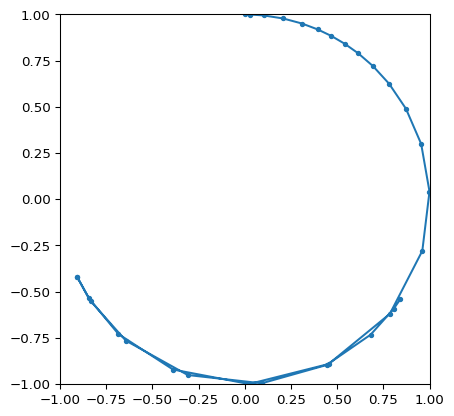

In [4]:
state_traj = np.array([sol.value(state) for state in states])

print("Cost", sol.value(cost))
fig, ax = plt.subplots()

# states, controls = simulate(initial_state, no_control_policy, num_steps, dt)
xs = np.sin(state_traj[:, 0]) * l
ys = -np.cos(state_traj[:, 0]) * l
ax.plot(xs, ys, ".-")
ax.set_aspect("equal")
ax.set_ylim([-1, 1])
ax.set_xlim([-1, 1])
print(xs[-1], ys[-1])

## Multiple Shooting

In [5]:
opti = ca.Opti()

num_steps = 100
num_knots = 5 # The number of knot points, including the beginning and end of the trajectory
knot_segment_lengths = [num_steps // (num_knots-1)] * (num_knots - 2)
knot_segment_lengths.append(num_steps - sum(knot_segment_lengths))

controls = opti.variable(num_steps, m)
state_knots = opti.variable(num_knots, n)

state_0 = opti.parameter(n)
state_f = opti.parameter(n)

def open_loop_policy(state, k):
    return controls[k, :]

cost = 0
Q = np.diag([10., 1.])
R = np.diag([0.1])
states = []
k_0 = 0
for idx, segment_length in enumerate(knot_segment_lengths):
    segment_states, segment_controls = simulate(state_knots[idx, :].T, open_loop_policy, segment_length, dt, k_0)
    states.append(segment_states)

    for state, control in zip(segment_states[:-1], segment_controls):
        cost += (ca.mtimes([(state - state_f).T, Q, state - state_f])
                 + ca.mtimes([control, R, control.T]))
    
    opti.subject_to(segment_states[-1] == state_knots[idx+1, :].T)
    k_0 += segment_length

opti.minimize(cost)

print("Setting Constraints")
opti.subject_to(state_knots[-1, :].T == state_f)
opti.subject_to(state_knots[0, :].T == state_0)
opti.subject_to(opti.bounded(-3.0, controls, 3.0))

print("Setting up problem")
opti.solver("ipopt")
opti.set_value(state_0, initial_state)
opti.set_value(state_f, goal_state)

print("Solving")
sol = opti.solve()

Setting Constraints
Setting up problem
Solving


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      228
Number of nonzeros in inequality constraint Jacobian.:      100
Number of nonzeros in Lagrangian Hessian.............:     1512

Total number of variables............................:      110
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       12
Total number of inequality constraints...............:      100
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      100
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  9.8696044e+03 3.14e+00 2.33e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

   6  9.2545099e+03 1.61e+00 3.60e+01  -1.0 3.24e+01    -  5.63e-02 5.57e-02h  1
   7  9.2960345e+03 1.56e+00 3.43e+01  -1.0 6.21e+01    -  7.47e-02 3.59e-02h  1
   8  9.3206072e+03 1.52e+00 3.24e+01  -1.0 3.24e+01    -  4.93e-02 2.17e-02h  1
   9  9.4374338e+03 1.41e+00 2.22e+01  -1.0 6.37e+01    -  2.32e-02 7.25e-02h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  9.4424911e+03 1.40e+00 2.20e+01  -1.0 5.23e+01    -  4.43e-02 5.55e-03h  1
  11  9.5111756e+03 1.33e+00 2.66e+01  -1.0 5.78e+01    -  6.75e-02 5.60e-02h  1
  12  9.5155785e+03 1.32e+00 2.66e+01  -1.0 7.91e+01    -  2.93e-02 4.22e-03h  1
  13  9.6242666e+03 1.24e+00 3.28e+01  -1.0 8.59e+01    -  8.53e-03 6.15e-02h  1


  14  9.6256494e+03 1.24e+00 3.27e+01  -1.0 5.08e+01    -  3.33e-02 1.56e-03h  1
  15  9.6727202e+03 1.19e+00 3.46e+01  -1.0 9.07e+01    -  2.28e-02 3.65e-02h  1
  16  9.6847737e+03 1.18e+00 3.45e+01  -1.0 7.30e+01    -  2.59e-02 1.16e-02h  1
  17  9.7172409e+03 1.15e+00 3.50e+01  -1.0 6.00e+01    -  4.45e-03 2.23e-02h  1
  18  9.8028298e+03 1.09e+00 4.45e+01  -1.0 5.98e+01    -  2.32e-02 5.38e-02h  1
  19  9.8196813e+03 1.07e+00 4.55e+01  -1.0 7.40e+01    -  7.55e-02 1.58e-02h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  9.8433360e+03 1.05e+00 4.81e+01  -1.0 5.99e+01    -  6.26e-02 2.38e-02h  1


  21  9.8487907e+03 1.04e+00 4.81e+01  -1.0 7.66e+01    -  2.01e-02 8.27e-03h  1
  22  9.8569764e+03 1.03e+00 4.93e+01  -1.0 1.18e+02    -  5.52e-02 1.32e-02h  1
  23  9.8725131e+03 1.00e+00 5.27e+01  -1.0 9.86e+01    -  3.12e-02 2.03e-02h  1
  24  9.9649982e+03 9.49e-01 8.91e+01  -1.0 1.02e+02    -  2.96e-03 5.53e-02h  1
  25  9.9656002e+03 9.48e-01 8.91e+01  -1.0 7.60e+01    -  1.93e-02 7.45e-04h  1
  26  9.9913638e+03 9.25e-01 9.19e+01  -1.0 6.85e+01    -  9.30e-04 2.41e-02h  1
  27  1.0037322e+04 8.84e-01 1.04e+02  -1.0 7.45e+01    -  2.47e-02 4.42e-02h  1


...

 139  9.4390008e+03 2.15e-01 5.43e+01  -1.0 1.06e+02    -  3.40e-03 3.44e-02f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 140  9.4326677e+03 1.36e-01 3.43e+01  -1.0 1.01e+00  -0.1 1.00e+00 3.70e-01f  1
 141  9.4277764e+03 1.82e-01 4.24e+01  -1.0 4.65e+00  -0.5 4.04e-02 4.35e-01f  1
 142  9.4225067e+03 1.56e-01 3.59e+01  -1.0 2.32e+00  -0.1 8.50e-01 1.98e-01f  1
 143  9.4106935e+03 1.72e-02 2.96e+00  -1.0 6.01e-01   0.3 1.00e+00 1.00e+00f  1
 144  9.3997135e+03 9.73e-02 2.02e+01  -1.0 5.67e+00  -0.2 3.93e-01 2.22e-01f  1
 145  9.3854400e+03 2.09e-02 3.03e+00  -1.0 1.08e+00   0.3 1.00e+00 1.00e+00f  1


 146  9.3695546e+03 8.39e-02 1.61e+01  -1.0 6.43e+00  -0.2 2.86e-01 2.42e-01f  1
 147  9.3686608e+03 8.40e-02 1.62e+01  -1.0 2.44e+02    -  5.83e-03 5.76e-04f  1
 148  9.3541642e+03 1.68e-01 4.23e+01  -1.0 3.72e+01    -  7.54e-02 8.77e-02f  1
 149  9.3467620e+03 1.60e-01 4.10e+01  -1.0 4.34e+00  -0.7 4.10e-01 3.23e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 150  9.3426850e+03 5.68e-02 1.35e+01  -1.0 9.78e-01  -0.3 8.24e-01 7.47e-01f  1
 151  9.3389954e+03 3.30e-03 8.05e-01  -1.0 2.99e-01   0.2 1.00e+00 1.00e+00f  1
 152  9.3304908e+03 1.11e-01 2.79e+01  -1.7 2.68e+00  -0.3 3.08e-01 5.60e-01f  1


 153  9.3154820e+03 5.69e-02 1.44e+01  -1.7 9.94e-01   0.1 9.17e-01 1.00e+00f  1
 154  9.3090494e+03 1.28e-02 3.02e+00  -1.7 4.39e-01   0.5 1.00e+00 1.00e+00f  1
 155  9.2973177e+03 1.14e-01 3.02e+01  -1.7 2.35e+00   0.1 3.65e-01 5.12e-01f  1
 156  9.2968902e+03 1.14e-01 3.02e+01  -1.7 4.91e+02  -0.4 2.00e-03 7.42e-05f  1
 157  9.2813283e+03 1.13e-01 2.80e+01  -1.7 2.54e+00   0.0 7.04e-01 5.89e-01f  1
 158  9.2810464e+03 1.12e-01 2.79e+01  -1.7 3.83e+00  -0.5 2.12e-01 4.83e-03f  1
 159  9.2694551e+03 1.62e-01 4.62e+01  -1.7 2.21e+01    -  1.54e-01 1.07e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 160  9.2686832e+03 1.58e-01 4.50e+01  -1.7 5.66e+00  -0.9 2.16e-01 3.01e-02f  1


 161  9.2643576e+03 2.60e-01 7.99e+01  -1.7 1.90e+02    -  8.10e-04 1.36e-02f  1
 162  9.2639140e+03 2.51e-01 7.73e+01  -1.7 1.20e+00  -0.5 1.00e+00 3.20e-02f  1
 163  9.2589596e+03 1.61e-01 4.95e+01  -1.7 2.05e+00  -1.0 1.00e+00 3.79e-01f  1
 164  9.2566078e+03 1.24e-01 3.81e+01  -1.7 2.20e+00    -  1.00e+00 2.32e-01f  1
 165  9.2522308e+03 8.38e-04 4.15e-01  -1.7 1.86e+00    -  1.00e+00 1.00e+00f  1
 166  9.2522972e+03 2.31e-06 8.36e-04  -1.7 6.04e-02    -  1.00e+00 1.00e+00h  1
 167  9.2495709e+03 2.98e-04 9.24e-02  -3.8 2.94e-01    -  9.52e-01 8.88e-01f  1
 168  9.2492086e+03 5.26e-06 1.77e-03  -3.8 8.93e-02    -  1.00e+00 1.00e+00f  1


 169  9.2492068e+03 7.88e-08 2.66e-05  -3.8 3.02e-02    -  1.00e+00 1.00e+00h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 170  9.2491835e+03 3.41e-08 1.07e-05  -5.7 9.66e-03    -  1.00e+00 1.00e+00f  1
 171  9.2491831e+03 1.64e-11 4.89e-09  -8.6 6.54e-04    -  1.00e+00 1.00e+00h  1
 172  9.2491831e+03 6.48e-14 1.63e-11  -8.6 2.61e-06    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 172

                                   (scaled)                 (unscaled)
Objective...............:   5.5792852517254641e+03    9.2491831432798153e+03
Dual infeasibility......:   1.6314061213051900e-11    2.7044994683419264e-11
Constraint violation....:   6.4781513486877884e-14    6.4781513486877884e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5070190967406822e-09    4.1560661846933467e-09
Overall NLP error.......:   2.5070190967406822e-09    4.1560661846933467e-09


Number of objective function

Cost 9249.183143279815
-2.2081995812588396e-14 1.0


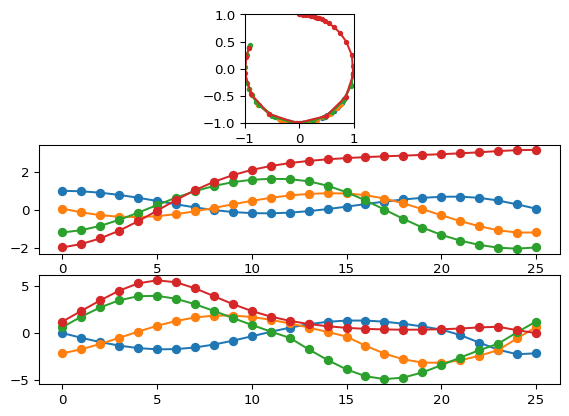

In [6]:
segment_trajs = [
    np.array([sol.value(state) for state in segment])
    for segment in states
]

print("Cost", sol.value(cost))

fig, ax = plt.subplots(3)
for state_traj in segment_trajs:
    xs = np.sin(state_traj[:, 0]) * l
    ys = -np.cos(state_traj[:, 0]) * l
    ax[0].plot(xs, ys, ".-")
    ax[1].plot(state_traj[:, 0], "-o")
    ax[2].plot(state_traj[:, 1], "-o")
ax[0].set_aspect("equal")
ax[0].set_ylim([-1, 1])
ax[0].set_xlim([-1, 1])
print(xs[-1], ys[-1])


## Trapezoidal Collocation

In [7]:
opti = ca.Opti()

num_collocation_points = 101
final_time = 10.0
# Linear spacing of collocation points
collocation_time_points = np.linspace(0, final_time, num_collocation_points)
dtq = collocation_time_points[1] - collocation_time_points[0]

controls = opti.variable(num_collocation_points, m)
states = opti.variable(num_collocation_points, n)

state_0 = opti.parameter(n)
state_f = opti.parameter(n)

cost = 0
Q = np.diag([10., 1.])
R = np.diag([0.1])
for segment in range(num_collocation_points - 1):
    cost += 0.5 * dtq * (
        ca.mtimes([(states[segment, :].T - state_f).T, Q, states[segment, :].T - state_f])
        + ca.mtimes([(controls[segment, :]).T, R, controls[segment, :]])
        + ca.mtimes([(states[segment+1, :].T - state_f).T, Q, states[segment+1, :].T - state_f])
        + ca.mtimes([(controls[segment+1, :]).T, R, controls[segment+1, :]])
    )
    opti.subject_to((states[segment+1, :] - states[segment, :]).T
                    == 0.5*dtq*(continuous_dynamics(states[segment+1, :], controls[segment+1, :])
                                + continuous_dynamics(states[segment, :], controls[segment, :])))

opti.minimize(cost)

print("Setting Constraints")
opti.subject_to(states[-1, :].T == state_f)
opti.subject_to(states[0, :].T == state_0)
opti.subject_to(opti.bounded(-3.0, controls, 3.0))

print("Setting up problem")
opti.solver("ipopt")
opti.set_value(state_0, initial_state)
opti.set_value(state_f, goal_state)

print("Solving")
sol = opti.solve()

Setting Constraints
Setting up problem
Solving
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1004
Number of nonzeros in inequality constraint Jacobian.:      101
Number of nonzeros in Lagrangian Hessian.............:      404

Total number of variables............................:      303
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      204
Total number of inequality constraints...............:      101
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      101
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  9.8696044e+02 3.14e+00 3

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  1.0214193e+03 7.63e-01 3.55e+00  -1.0 6.69e+01    -  3.92e-02 2.87e-02h  1
  21  1.0192531e+03 7.21e-01 3.97e+00  -1.0 7.23e+01    -  2.36e-02 5.47e-02f  1
  22  1.0182028e+03 7.11e-01 3.98e+00  -1.0 4.95e+01    -  6.68e-02 1.40e-02f  1
  23  1.0168911e+03 6.91e-01 3.95e+00  -1.0 1.05e+02    -  6.15e-02 2.72e-02f  1
  24  1.0159920e+03 6.62e-01 4.05e+00  -1.0 9.55e+01    -  2.22e-02 4.24e-02f  1
  25  1.0156953e+03 6.56e-01 4.05e+00  -1.0 7.91e+01    -  2.76e-02 8.65e-03h  1
  26  1.0146556e+03 6.25e-01 4.54e+00  -1.0 6.52e+01    -  1.88e-02 4.77e-02f  1
  27  1.0108440e+03 5.99e-01 4.81e+00  -1.0 7.02e+01    -  6.19e-02 4.22e-02f  1
  28  1.0095862e+03 5.91e-01 4.80e+00  -1.0 1.02e+02    -  6.18e-02 1.29e-02f  1
  29  1.0076672e+03 5.46e-01 6.81e+00  -1.0 6.12e+01    -  2.03e-02 7.66e-02f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  1.0071302e+03 5.42e-01

  79  8.8442773e+02 2.97e-01 2.40e+01  -1.0 7.97e+02    -  1.25e-04 6.81e-04f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  80  8.8440265e+02 2.97e-01 2.25e+01  -1.0 7.82e+02    -  1.20e-03 5.69e-05h  1
  81  8.8431476e+02 2.94e-01 4.74e+00  -1.0 7.26e+02    -  2.60e-04 7.96e-03f  1
  82  8.8390618e+02 2.94e-01 4.63e+00  -1.0 7.86e+02    -  2.51e-03 4.01e-04h  1
  83  8.8118907e+02 2.93e-01 1.31e+01  -1.0 7.72e+02    -  4.59e-03 2.48e-03f  1
  84  8.8013889e+02 2.93e-01 9.40e+00  -1.0 1.43e+03    -  2.47e-03 6.11e-04f  1
  85  8.7717603e+02 2.93e-01 7.77e+00  -1.0 1.38e+03    -  2.43e-03 1.96e-03f  1
  86  8.7688027e+02 2.92e-01 4.44e+00  -1.0 1.21e+03    -  1.15e-04 3.35e-03f  1
  87  8.7651303e+02 2.91e-01 4.42e+00  -1.0 1.36e+03    -  1.80e-03 1.31e-03f  1
  88  8.7608022e+02 2.91e-01 4.42e+00  -1.0 1.82e+03    -  1.09e-03 2.91e-04f  1
  89  8.7348767e+02 2.91e-01 4.35e+00  -1.0 1.85e+03    -  1.56e-03 2.23e-03f  1
iter    objective    inf_pr 

Cost 897.8865349154371
1.2246467991473532e-16 1.0


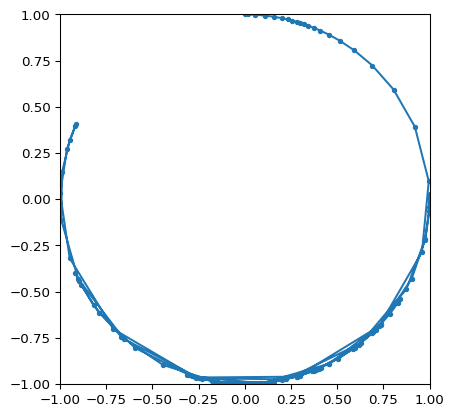

In [8]:
state_traj = np.array(sol.value(states))

print("Cost", sol.value(cost))
fig, ax = plt.subplots()

# states, controls = simulate(initial_state, no_control_policy, num_steps, dt)
xs = np.sin(state_traj[:, 0]) * l
ys = -np.cos(state_traj[:, 0]) * l
ax.plot(xs, ys, ".-")
ax.set_aspect("equal")
ax.set_ylim([-1, 1])
ax.set_xlim([-1, 1])
print(xs[-1], ys[-1])

## Hermite-Simpson Collocation

In [9]:
opti = ca.Opti()

num_collocation_points = 101
final_time = 10.0
# Linear spacing of collocation points
collocation_time_points = np.linspace(0, final_time, num_collocation_points)
dtq = collocation_time_points[1] - collocation_time_points[0]

controls = opti.variable(num_collocation_points, m)
half_controls = opti.variable(num_collocation_points - 1, m)
states = opti.variable(num_collocation_points, n)

state_0 = opti.parameter(n)
state_f = opti.parameter(n)

cost = 0
Q = np.diag([10., 1.])
R = np.diag([0.1])
def stage_cost(state, control):
    return ca.mtimes([(state - state_f).T, Q, state - state_f]) + ca.mtimes([control.T, R, control])
for segment in range(num_collocation_points - 1):
    half_state = 0.5 * (states[segment, :] + states[segment+1, :]).T + dtq / 8 * (
        continuous_dynamics(states[segment, :], controls[segment, :])
        - continuous_dynamics(states[segment+1, :], controls[segment+1, :])
    )
    cost += dtq/6 *(stage_cost(states[segment, :].T, controls[segment, :].T)
                    + stage_cost(states[segment+1, :].T, controls[segment+1, :].T)
                    + stage_cost(half_state, half_controls[segment, :].T))

    opti.subject_to((states[segment+1, :] - states[segment, :]).T
                    == dtq/6*(continuous_dynamics(states[segment+1, :], controls[segment+1, :])
                                + continuous_dynamics(states[segment, :], controls[segment, :])
                                + 4*continuous_dynamics(half_state, half_controls[segment, :])))

opti.minimize(cost)

print("Setting Constraints")
opti.subject_to(states[-1, :].T == state_f)
opti.subject_to(states[0, :].T == state_0)
opti.subject_to(opti.bounded(-3.0, controls, 3.0))
opti.subject_to(opti.bounded(-3.0, half_controls, 3.0))

print("Setting up problem")
opti.solver("ipopt")
opti.set_value(state_0, initial_state)
opti.set_value(state_f, goal_state)

print("Solving")
sol = opti.solve()

Setting Constraints
Setting up problem
Solving


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1304
Number of nonzeros in inequality constraint Jacobian.:      201
Number of nonzeros in Lagrangian Hessian.............:     1606

Total number of variables............................:      403
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      204
Total number of inequality constraints...............:      201
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      201
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.9348022e+02 3.14e+00 1.30e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  5.3416999e+02 7.22e-01 3.92e+00  -1.0 5.09e+01    -  3.52e-02 2.32e-02f  1
  21  5.3219890e+02 6.96e-01 3.99e+00  -1.0 8.31e+01    -  1.50e-01 3.55e-02f  1
  22  5.3168692e+02 6.84e-01 3.89e+00  -1.0 1.70e+02    -  2.23e-02 1.74e-02f  1
  23  5.3086806e+02 6.36e-01 4.72e+00  -1.0 3.83e+01    -  6.35e-02 6.97e-02h  1
  24  5.2813861e+02 5.97e-01 4.57e+00  -1.0 7.82e+01    -  2.51e-02 6.18e-02f  1
  25  5.2724522e+02 5.85e-01 4.50e+00  -1.0 5.91e+01    -  8.56e-02 2.03e-02f  1
  26  5.2588864e+02 5.69e-01 4.35e+00  -1.0 8.49e+01    -  4.52e-02 2.73e-02f  1
  27  5.2355778e+02 5.32e-01 4.91e+00  -1.0 3.18e+01    -  2.56e-02 6.57e-02f  1
  28  5.2090809e+02 5.13e-01 4.90e+00  -1.0 1.01e+02    -  1.27e-01 3.46e-02f  1
  29  5.1910941e+02 4.95e-01 4.66e+00  -1.0 9.09e+01    -  1.03e-01 3.60e-02f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  5.1613103e+02 4.67e-01

  43  4.8335605e+02 3.33e-01 5.08e+00  -1.0 1.02e+02    -  1.77e-02 1.34e-02f  1
  44  4.8128982e+02 3.29e-01 4.81e+00  -1.0 3.28e+02    -  1.18e-02 1.29e-02f  1
  45  4.7893683e+02 3.24e-01 4.58e+00  -1.0 2.75e+02    -  9.39e-03 1.33e-02f  1
  46  4.7754041e+02 3.22e-01 4.55e+00  -1.0 2.07e+02    -  1.46e-02 7.71e-03f  1
  47  4.7591950e+02 3.19e-01 4.67e+00  -1.0 1.40e+02    -  1.68e-02 9.45e-03f  1
  48  4.7350218e+02 3.14e-01 4.20e+00  -1.0 1.76e+02    -  4.58e-03 1.64e-02f  1
  49  4.7181778e+02 3.11e-01 4.08e+00  -1.0 3.52e+02    -  5.39e-03 7.83e-03f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  50  4.6933355e+02 3.08e-01 3.95e+00  -1.0 4.87e+02    -  7.69e-03 8.63e-03f  1
  51  4.6877687e+02 3.08e-01 3.94e+00  -1.0 1.61e+02    -  1.53e-02 2.68e-03f  1
  52  4.6666103e+02 3.04e-01 3.81e+00  -1.0 3.80e+02    -  4.47e-03 1.19e-02f  1
  53  4.6530299e+02 3.02e-01 3.74e+00  -1.0 3.99e+02    -  4.10e-03 6.93e-03f  1
  54  4.6425984e+02 3.00e-01

  67  4.5216842e+02 2.84e-01 1.33e+01  -1.0 3.63e+02  -2.0 1.50e-03 1.28e-02f  1
  68  4.5314668e+02 2.81e-01 1.33e+01  -1.0 1.68e+02    -  1.88e-02 1.15e-02h  1
  69  4.5550006e+02 2.73e-01 1.31e+01  -1.0 1.23e+02    -  2.79e-02 2.56e-02h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  70  4.5489503e+02 2.73e-01 1.33e+01  -1.0 1.38e+03  -2.5 1.30e-03 3.13e-03f  1
  71  4.5605155e+02 2.68e-01 1.21e+01  -1.0 1.46e+02    -  5.96e-03 1.68e-02h  1
  72  4.5804928e+02 2.58e-01 1.26e+01  -1.0 1.48e+02    -  8.22e-02 3.81e-02h  1
  73  4.5930968e+02 2.50e-01 1.21e+01  -1.0 1.82e+02    -  2.69e-02 2.96e-02h  1
  74  4.5983220e+02 2.47e-01 1.09e+01  -1.0 3.55e+01  -1.1 4.43e-03 1.31e-02h  1
  75  4.6122525e+02 2.28e-01 8.64e+00  -1.0 6.94e+01  -1.6 3.46e-02 7.68e-02h  1
  76  4.6144242e+02 2.26e-01 9.03e+00  -1.0 2.33e+01  -1.2 1.88e-02 9.49e-03h  1
  77  4.6071907e+02 2.24e-01 9.22e+00  -1.0 1.39e+02  -1.7 4.25e-02 8.35e-03f  1
  78  4.6078020e+02 2.19e-01

...

 363  3.8959429e+02 1.56e-03 1.92e-01  -3.8 5.48e-01  -0.9 1.00e+00 3.47e-01f  1
 364  3.8939618e+02 9.58e-04 1.27e-01  -3.8 1.20e+00  -1.4 6.32e-01 4.19e-01f  1
 365  3.8924882e+02 2.74e-04 4.72e-02  -3.8 4.58e-01  -1.0 1.00e+00 7.52e-01f  1
 366  3.8910027e+02 3.10e-04 4.95e-02  -3.8 1.69e+00  -1.5 1.60e-01 2.83e-01f  1
 367  3.8897545e+02 1.03e-04 5.59e-02  -3.8 5.13e-01  -1.0 6.16e-01 1.00e+00f  1
 368  3.8857755e+02 2.10e-03 2.98e-01  -3.8 2.82e+00  -1.5 1.24e-01 6.06e-01f  1
 369  3.8824452e+02 6.53e-04 1.13e-01  -3.8 9.76e-01  -1.1 5.86e-01 7.97e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 370  3.8778441e+02 1.87e-03 2.79e-01  -3.8 9.07e+00  -1.6 1.09e-01 1.46e-01f  1
 371  3.8778125e+02 1.87e-03 2.79e-01  -3.8 1.54e+01  -2.0 6.32e-02 7.05e-04f  1
 372  3.8753417e+02 1.78e-03 2.49e-01  -3.8 3.97e+00  -1.6 9.57e-02 1.82e-01f  1
 373  3.8700333e+02 1.58e-03 1.57e-01  -3.8 1.38e+00  -1.2 7.84e-01 1.00e+00f  1
 374  3.8690889e+02 1.56e-03

 384  3.8458428e+02 4.52e-04 6.65e-02  -3.8 1.19e+00  -1.4 3.25e-01 7.93e-01f  1
 385  3.8451099e+02 2.61e-04 4.30e-02  -3.8 4.62e-01  -1.0 8.45e-01 4.91e-01f  1
 386  3.8430497e+02 9.69e-04 1.47e-01  -3.8 1.80e+00  -1.5 4.52e-01 7.65e-01f  1
 387  3.8410856e+02 5.11e-04 7.81e-02  -3.8 8.11e-01  -1.1 7.94e-01 6.46e-01f  1
 388  3.8401258e+02 5.49e-04 8.40e-02  -3.8 5.16e+00  -1.5 1.04e-01 6.53e-02f  1
 389  3.8364089e+02 8.37e-04 1.30e-01  -3.8 1.17e+00  -1.1 9.68e-01 1.00e+00f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 390  3.8338469e+02 1.17e-03 1.80e-01  -3.8 2.03e+01  -1.6 3.04e-02 3.37e-02f  1
 391  3.8302480e+02 2.19e-03 2.51e-01  -3.8 1.87e+01  -2.1 4.87e-02 9.15e-02f  1
 392  3.8285842e+02 2.40e-03 2.55e-01  -3.8 1.39e+01  -2.6 1.26e-02 6.17e-02f  1
 393  3.8281957e+02 2.39e-03 2.54e-01  -3.8 2.39e+01  -2.1 6.20e-02 6.12e-03f  1
 394  3.8238127e+02 1.43e-03 1.80e-01  -3.8 1.76e+00  -1.7 3.75e-01 7.33e-01f  1
 395  3.8203305e+02 2.09e-03

 405  3.8070561e+02 1.16e-03 1.72e-01  -3.8 1.49e+00  -1.5 5.03e-01 9.92e-01f  1
 406  3.8043817e+02 3.34e-04 5.58e-02  -3.8 7.06e-01  -1.1 1.00e+00 1.00e+00f  1
 407  3.8001013e+02 2.39e-03 3.61e-01  -3.8 6.54e+00  -1.6 9.61e-02 2.81e-01f  1
 408  3.7984190e+02 2.05e-03 3.10e-01  -3.8 1.88e+00  -1.2 1.61e-01 1.72e-01f  1
 409  3.7962460e+02 1.80e-03 2.57e-01  -3.8 3.89e+00  -1.6 1.49e-01 2.11e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 410  3.7947822e+02 1.60e-03 2.24e-01  -3.8 3.67e+00  -2.1 9.85e-02 1.67e-01f  1
 411  3.7928433e+02 1.83e-03 2.32e-01  -3.8 1.29e+01  -2.6 5.69e-02 8.58e-02f  1
 412  3.7925198e+02 1.78e-03 2.26e-01  -3.8 4.41e+00  -2.2 2.96e-02 2.94e-02f  1
 413  3.7899169e+02 1.14e-03 1.43e-01  -3.8 1.94e+00  -1.7 4.32e-01 5.52e-01f  1
 414  3.7874116e+02 1.82e-03 2.32e-01  -3.8 1.65e+01  -2.2 5.44e-02 9.50e-02f  1
 415  3.7870746e+02 1.76e-03 2.24e-01  -3.8 3.07e+00  -1.8 4.99e-01 3.43e-02f  1
 416  3.7841080e+02 2.37e-03

 426  3.7763291e+02 1.07e-04 3.25e-02  -3.8 4.45e-01  -1.1 1.00e+00 1.00e+00f  1
 427  3.7753943e+02 3.62e-04 7.03e-02  -3.8 3.95e+00  -1.6 3.30e-01 1.81e-01f  1
 428  3.7741005e+02 3.24e-04 5.43e-02  -3.8 9.14e-01  -1.2 1.00e+00 6.73e-01f  1
 429  3.7698248e+02 3.09e-03 4.71e-01  -3.8 1.30e+01  -1.7 8.93e-02 1.68e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 430  3.7683487e+02 2.38e-03 3.65e-01  -3.8 1.62e+00  -1.2 3.35e-01 2.40e-01f  1
 431  3.7676535e+02 2.42e-03 3.67e-01  -3.8 5.82e+01    -  3.09e-03 9.18e-03f  1
 432  3.7651360e+02 1.33e-03 1.87e-01  -3.8 1.52e+00  -1.7 8.12e-01 5.17e-01f  1
 433  3.7634801e+02 2.35e-03 3.07e-01  -3.8 1.33e+01  -2.2 5.54e-02 1.35e-01f  1
 434  3.7609897e+02 1.55e-03 1.92e-01  -3.8 2.22e+00  -1.8 6.13e-01 4.39e-01f  1
 435  3.7583040e+02 2.86e-03 3.76e-01  -3.8 9.11e+00  -2.2 1.30e-01 2.64e-01f  1
 436  3.7564975e+02 2.42e-03 3.21e-01  -3.8 3.02e+00  -1.8 4.46e-01 1.87e-01f  1
 437  3.7554897e+02 2.35e-03

 445  3.7514160e+02 1.13e-08 3.29e-07  -5.7 4.49e-02    -  1.00e+00 1.00e+00f  1
 446  3.7514131e+02 2.05e-09 1.80e-07  -8.6 1.94e-02    -  9.98e-01 1.00e+00h  1
 447  3.7514131e+02 9.40e-11 1.51e-10  -8.6 4.38e-03    -  1.00e+00 1.00e+00h  1
 448  3.7514131e+02 3.02e-13 4.69e-13  -8.6 2.48e-04    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 448

                                   (scaled)                 (unscaled)
Objective...............:   3.7514131152019775e+02    3.7514131152019775e+02
Dual infeasibility......:   4.6940229481151619e-13    4.6940229481151619e-13
Constraint violation....:   3.0157126795771205e-13    3.0157126795771205e-13
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.7446016559877068e-09    2.7446016559877068e-09
Overall NLP error.......:   2.7446016559877068e-09    2.7446016559877068e-09


Number of objective function evaluations             = 466
Number of objective gradient evaluations          

Cost 375.14131152019775
1.2246467991473532e-16 1.0


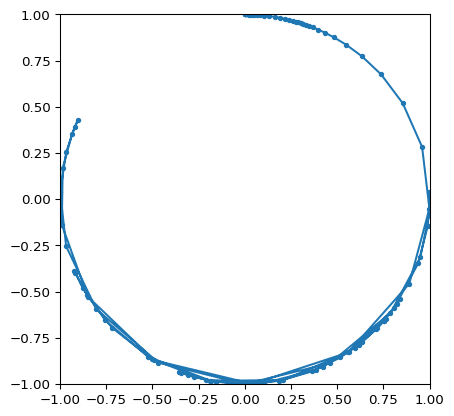

In [10]:
state_traj = np.array(sol.value(states))

print("Cost", sol.value(cost))
fig, ax = plt.subplots()

# states, controls = simulate(initial_state, no_control_policy, num_steps, dt)
xs = np.sin(state_traj[:, 0]) * l
ys = -np.cos(state_traj[:, 0]) * l
ax.plot(xs, ys, ".-")
ax.set_aspect("equal")
ax.set_ylim([-1, 1])
ax.set_xlim([-1, 1])
print(xs[-1], ys[-1])

## Orthogonal Collocation

You have K knot points and C collocation points. Knot points are the points where the polynomial segments meet. Collocation points are the points where the dynamics are enforced (generally many collocation points between knot points). 

Below is an example using Legndre Gauss points, separated form

In [11]:
def normalize_interval(t, t_lo, t_hi):
    """Calculate the normalized time parameter for [-1, 1]"""
    return (t - t_lo) / (t_hi - t_lo) * 2 - 1

def legendre_gauss_quadrature(func_values, collocation_points):
    """
    Args: 
        func_values: a vector of function values at the collocation points
        collocation_points: the collocation points in [-1, 1]
    """
    interp_weights = np.prod(collocation_points[:, None] - collocation_points[None, :] + np.eye(len(collocation_points)), axis=1)
    quadrature_weights = interp_weights**2 / (1-collocation_points**2)
    quadrature_weights = quadrature_weights / np.sum(quadrature_weights) * 2
    return func_values @ quadrature_weights

def barycentric_interpolation(values, collocation_points, t):
    """Interpolate the polynomial defined by the values at the collocation points to time t

    Args:
        values: a vector of function values at the collocation points
        collocation_points: the collocation points in [-1, 1]
        t: the time to interpolate to in [-1, 1]
    """
    interp_weights = np.prod(collocation_points[:, None] - collocation_points[None, :] + np.eye(len(collocation_points)), axis=1)
    weighted_weights = interp_weights / (t - collocation_points)
    return weighted_weights @ values / np.sum(weighted_weights)

def differentiate(values, collocation_points):
    interp_weights = np.prod(collocation_points[:, None] - collocation_points[None, :] + np.eye(len(collocation_points)), axis=1)
    diff_matrix = interp_weights[None, :] / interp_weights[:, None] / (collocation_points[:, None] - collocation_points[None, :] + np.eye(len(collocation_points))) - np.eye(len(collocation_points))
    diff_matrix = diff_matrix - np.diag(np.sum(diff_matrix, axis=1))
    return diff_matrix @ values

final_time = 10.0
num_segments = 10
num_knot_points = num_segments + 1
knot_points = np.linspace(0, final_time, num_knot_points)
degree = 3  # the degree of the dynamics approximation, also the number of collocation points per segment
            # will also be the degree of control approx and deg+1 for state approx

roots = ca.collocation_points(degree, "legendre") # legendre gauss points
roots = np.array(roots)*2 - 1  # normalize from [0, 1] to [-1, 1]

controls = opti.variable(num_segments*degree, m)
collocation_states = opti.variable(num_segments*degree, n)
knot_states = opti.variable(num_knot_points, n)

state_0 = opti.parameter(n)
state_f = opti.parameter(n)

cost = 0
Q = np.diag([10., 1.])
R = np.diag([0.1])
def stage_cost(state, control):
    """Expects vectors"""
    return ca.mtimes([(state - state_f).T, Q, state - state_f]) + ca.mtimes([control.T, R, control])

for segment in range(num_segments):
    collocation_costs = []
    for idx, collocation_point in enumerate(roots):
        collocation_costs.append(stage_cost(
            collocation_states[segment*degree + idx, :].T,
            controls[segment*degree + idx, :].T
        ))
    collocation_costs = ca.hcat(collocation_costs)
    cost += legendre_gauss_quadrature(collocation_costs, roots)

    # Collocation Constraints (dynamics)
    dynamics_at_collocation_points = []
    for idx, collocation_point in enumerate(roots):
        dynamics_at_collocation_points.append(continuous_dynamics(
            collocation_states[segment*degree + idx, :].T,
            controls[segment*degree + idx, :].T
        ))
    dynamics_at_collocation_points = ca.hcat(dynamics_at_collocation_points)
    opti.subject_to(knot_states[segment+1, :].T - knot_states[segment, :].T
                    == legendre_gauss_quadrature(dynamics_at_collocation_points, roots))

    # Interpolation Constraints
    opti.subject_to(
        differentiate(collocation_states[segment*degree:(segment+1)*degree, :], roots)
        == dynamics_at_collocation_points.T
    )


opti.minimize(cost)

print("Setting Constraints")
opti.subject_to(knot_states[-1, :].T == state_f)
opti.subject_to(knot_states[0, :].T == state_0)
opti.subject_to(opti.bounded(-3.0, controls, 3.0))

print("Setting up problem")
opti.solver("ipopt")
opti.set_value(state_0, initial_state)
opti.set_value(state_f, goal_state)

print("Solving")
sol = opti.solve()


Setting Constraints


Setting up problem
Solving


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1738
Number of nonzeros in inequality constraint Jacobian.:      231
Number of nonzeros in Lagrangian Hessian.............:      823

Total number of variables............................:      515
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      288
Total number of inequality constraints...............:      231
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      231
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.9739209e+03 3.14e+00 2.12e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

  24  1.8259966e+03 2.26e-01 2.89e+00  -1.0 7.57e+01    -  3.16e-02 2.86e-02h  2
  25  1.8262855e+03 2.22e-01 2.83e+00  -1.0 1.05e+02    -  4.63e-02 1.66e-02h  2
  26  1.8298865e+03 1.76e-01 2.70e+00  -1.0 8.66e+00    -  2.09e-01 2.09e-01h  1
  27  1.8329342e+03 1.36e-01 2.39e+00  -1.0 2.03e+01    -  1.35e-01 2.23e-01H  1
  28  1.8361424e+03 9.52e-02 2.35e+00  -1.0 9.11e+00    -  6.23e-01 3.02e-01h  1
  29  1.8375568e+03 7.71e-02 1.99e+00  -1.0 2.65e+01    -  1.49e-01 1.90e-01H  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  1.8386744e+03 6.31e-02 1.67e+00  -1.0 1.66e+01    -  2.41e-01 1.85e-01h  1
  31  1.8436050e+03 4.22e-02 1.83e+00  -1.0 6.15e+00    -  1.00e+00 1.00e+00H  1
  32  1.8436048e+03 2.50e-02 1.79e+00  -1.0 1.84e+01    -  1.14e-01 1.22e-01h  1
  33  1.8436048e+03 3.03e-02 1.75e+00  -1.0 4.16e+01  -2.6 1.22e-01 4.52e-02f  1
  34  1.8436039e+03 1.88e-02 1.06e+00  -1.0 4.79e+00  -2.2 1.00e+00 1.00e+00F  1
  35  1.8436039e+03 2.93e-02

 |        0 (       0)   1.67ms ( 24.25us)        69
       nlp_g  |  33.00ms (478.26us)  29.55ms (428.20us)        69
  nlp_grad_f  |   2.00ms ( 41.67us)   2.34ms ( 48.79us)        48
  nlp_hess_l  |  90.00ms (  1.96ms)  85.36ms (  1.86ms)        46
   nlp_jac_g  |  73.00ms (  1.52ms)  71.12ms (  1.48ms)        48
       total  | 368.00ms (368.00ms) 367.56ms (367.56ms)         1


[ 3.00000003  0.51357576 -0.39204991  3.00000003  0.51357576 -0.39204991
  3.00000003  0.51357576 -0.39204991  3.00000003  0.51357576 -0.39204991
  3.00000003  0.51357576 -0.39204991  3.00000003  0.51357576 -0.39204991
  3.00000003  0.51357576 -0.39204991  3.00000003  0.51357576 -0.39204991
  3.00000003  0.51357576 -0.39204991  3.00000003  0.51357576 -0.39204991]
Cost 1842.605022453114
1.2246467991473532e-16 1.0


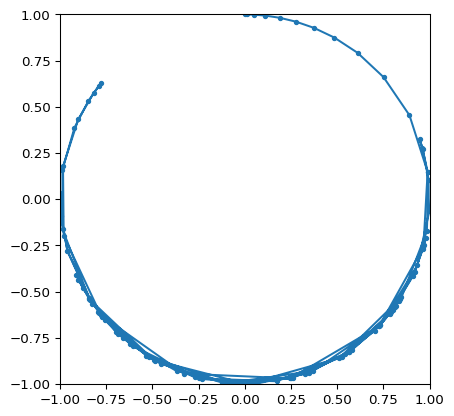

In [12]:
state_traj = np.array(sol.value(states))
control_traj = np.array(sol.value(controls))
print(control_traj)

print("Cost", sol.value(cost))
fig, ax = plt.subplots()

# states, controls = simulate(initial_state, no_control_policy, num_steps, dt)
xs = np.sin(state_traj[:, 0]) * l
ys = -np.cos(state_traj[:, 0]) * l
ax.plot(xs, ys, ".-")
ax.set_aspect("equal")
ax.set_ylim([-1, 1])
ax.set_xlim([-1, 1])
print(xs[-1], ys[-1])